# Tutorial 12 - add_equivalent_full_cycles

## Step 0: Setup the project and prepare the data

In [1]:
from pathlib import Path

import pydpeet as eet

We will use "ERROR" as the logging style for better readability of the notebook

In [2]:
eet.set_logging_style("ERROR")

In [3]:
standardized_data = eet.read(
    input_path=str(Path.cwd().parent.parent / "res" / "raw_data_from_cyclers" / "Cal_Ageing_Checkup1.xlsx"),
    config=eet.ReadConfig.Neware_8_0_0_516,
)

In [4]:
segmented_data = eet.add_primitive_segments(df=standardized_data, config=eet.PrimitiveConfig.OCV_ANALYSIS_DEFAULT)

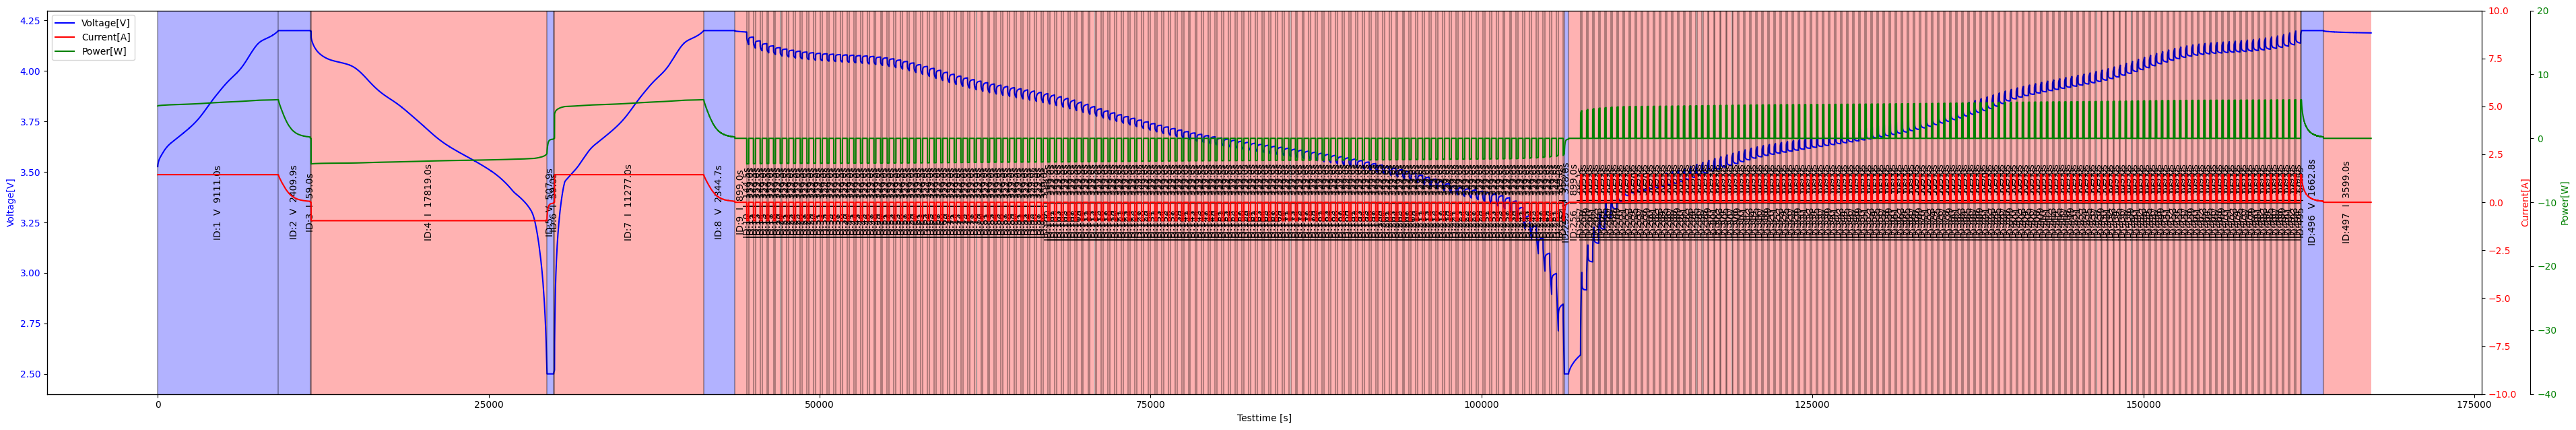

In [5]:
eet.visualize_phases(df=segmented_data, config=eet.VisualizationConfig.DEFAULT)

In [6]:
standardized_data = eet.add_capacity(
    df=standardized_data,
    df_primitives=segmented_data,
    config=eet.BatteryConfig.DEFAULT,
    neware_bool=True,
    verbose=True,
)

## Step 1: add_equivalent_full_cycles

<Axes: xlabel='Test_Time[s]'>

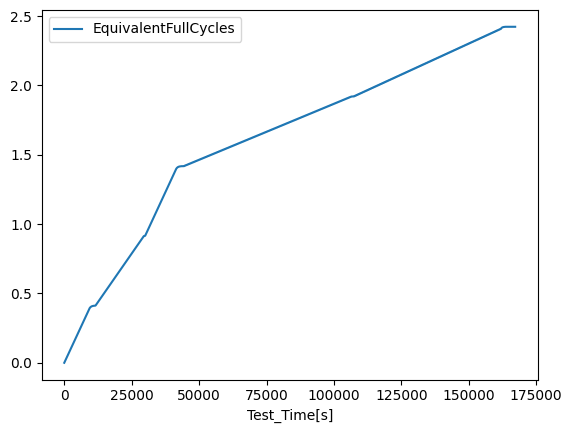

In [11]:
df = eet.add_equivalent_full_cycles(
    df=standardized_data,
    config=eet.BatteryConfig.DEFAULT,
    verbose=True,
)
df.plot(x="Test_Time[s]", y=["EquivalentFullCycles"])

In [8]:
added_cols = [c for c in df.columns if c not in standardized_data.columns]
added_cols

['ChargeThroughput[Ah]',
 'AbsoluteChargeThroughput[Ah]',
 'EquivalentFullCycles']